# Notebook 5: Transformer Encoder with BLOSUM62

The BiLSTM addressed the non-locality problem (strand pairing across distant residues)
by letting information flow across the whole sequence. However it still has to pass that
information step by step through a recurrent hidden state, so two residues 200
positions apart are only connected through ~200 sequential updates.

A Transformer encoder removes that bottleneck: self-attention lets every residue
attend directly to every other residue in a single layer, regardless of distance. For
β-strand pairing, where the relevant partner residue can be anywhere in the sequence,
this is a more direct architectural fit than recurrence.

### Trade-off
Attention has no built-in sequential/local inductive bias the way an LSTM does. It has
to learn positional relationships from data. With 599 proteins, this from-scratch
Transformer may not have enough data to beat the BiLSTM. That comparison, on identical
data and identical BLOSUM62 input, is the point of this notebook.

### Architecture
- Input: BLOSUM62 vectors (20-dim per residue), linearly projected to `d_model`
- Sinusoidal positional encoding added (Transformers have no notion of order otherwise)
- Transformer encoder: 3 layers × 4 heads × d_model=128, feedforward dim=512
- Classifier: Linear(128 → 3)
- Padding handled via `src_key_padding_mask` (excluded from attention) and
  `ignore_index=-1` in the loss (excluded from gradient)


In [1]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from Bio.Align import substitution_matrices
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

df = pd.read_csv("protein_sequences_ss_3.csv")
print(f"Loaded {len(df)} proteins")


Device: cuda
Loaded 599 proteins


In [2]:
# ── BLOSUM62 setup (identical to notebook 4) ──────────────────────────────────
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
aa_to_index = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

blosum = substitution_matrices.load("BLOSUM62")
blosum_matrix = np.array([
    [float(blosum[(aa1, aa2)]) for aa2 in AMINO_ACIDS]
    for aa1 in AMINO_ACIDS
])

def blosum_encode(aa):
    if aa not in aa_to_index:
        return np.zeros(20)
    return blosum_matrix[aa_to_index[aa]]

# Label encoder
le = LabelEncoder()
le.fit(["H", "E", "C"])
print("Classes:", le.classes_)


Classes: ['C' 'E' 'H']


In [3]:
# ── Protein-level split (same split as notebook 4 for a fair comparison) ─────
protein_ids = df.index.tolist()
train_ids, test_ids = train_test_split(protein_ids, test_size=0.2, random_state=42)
train_df = df.iloc[train_ids].reset_index(drop=True)
test_df  = df.iloc[test_ids].reset_index(drop=True)
print(f"Train: {len(train_df)} proteins | Test: {len(test_df)} proteins")

MAX_PROTEIN_LEN = df["sequence"].str.len().max()
print(f"Longest protein: {MAX_PROTEIN_LEN} residues")


Train: 479 proteins | Test: 120 proteins
Longest protein: 1000 residues


In [4]:
# ── Dataset (identical to notebook 4 — same features, same labels) ───────────
# Each sample is a whole protein. x shape: (seq_len, 20)   y shape: (seq_len,)
class ProteinDataset(Dataset):
    def __init__(self, df):
        self.samples = []
        for _, row in df.iterrows():
            x = torch.tensor(
                np.array([blosum_encode(aa) for aa in row["sequence"]]),
                dtype=torch.float32
            )
            y = torch.tensor(
                le.transform(list(row["secondary_structure"])),
                dtype=torch.long
            )
            self.samples.append((x, y))

    def __len__(self):             return len(self.samples)
    def __getitem__(self, idx):    return self.samples[idx]


In [5]:
# ── Collate: pad batch + build a padding mask for attention ──────────────────
# Unlike the BiLSTM, the Transformer needs an explicit mask: without it,
# self-attention would let real residues attend to zero-padded positions.
def collate_fn(batch):
    xs, ys  = zip(*batch)
    lengths = [x.shape[0] for x in xs]
    max_len = max(lengths)

    x_pad = torch.zeros(len(xs), max_len, 20)
    y_pad = torch.full((len(xs), max_len), fill_value=-1, dtype=torch.long)
    pad_mask = torch.ones(len(xs), max_len, dtype=torch.bool)   # True = padded

    for i, (x, y) in enumerate(zip(xs, ys)):
        L = x.shape[0]
        x_pad[i, :L]    = x
        y_pad[i, :L]    = y
        pad_mask[i, :L] = False

    return x_pad, y_pad, pad_mask, lengths


In [6]:
# ── Sinusoidal positional encoding ────────────────────────────────────────────
# Self-attention has no inherent notion of residue order. Without this, the
# model couldn't tell "MKV..." from "VKM...". Fixed (non-learned) encoding,
# added once at the input, following the original Transformer paper.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [7]:
# ── Model ──────────────────────────────────────────────────────────────────────
class ProteinTransformer(nn.Module):
    def __init__(self, input_size=20, d_model=128, nhead=4, num_layers=3,
                 dim_feedforward=512, num_classes=3, dropout=0.3, max_len=1200):
        super().__init__()
        self.input_proj  = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, pad_mask=None):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x, src_key_padding_mask=pad_mask)   # (batch, seq_len, d_model)
        x = self.dropout(x)
        return self.classifier(x)                            # (batch, seq_len, num_classes)


In [8]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
train_dataset = ProteinDataset(train_df)
test_dataset  = ProteinDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, collate_fn=collate_fn)


In [9]:
# ── Training utilities ─────────────────────────────────────────────────────────
model     = ProteinTransformer(max_len=int(MAX_PROTEIN_LEN) + 1).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=-1)   # -1 = padded positions
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

def train_epoch(model, loader):
    model.train()
    total = 0
    for x, y, pad_mask, _ in loader:
        x, y, pad_mask = x.to(device), y.to(device), pad_mask.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, pad_mask).view(-1, 3), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def compute_loss(model, loader):
    model.eval()
    total = 0
    with torch.no_grad():
        for x, y, pad_mask, _ in loader:
            x, y, pad_mask = x.to(device), y.to(device), pad_mask.to(device)
            total += criterion(model(x, pad_mask).view(-1, 3), y.view(-1)).item()
    return total / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y, pad_mask, lengths in loader:
            x, y, pad_mask = x.to(device), y.to(device), pad_mask.to(device)
            out = model(x, pad_mask).argmax(dim=-1)
            for i, l in enumerate(lengths):
                preds.extend(out[i, :l].cpu().numpy())
                labels.extend(y[i,  :l].cpu().numpy())
    return np.array(preds), np.array(labels)


Trainable parameters: 597,891


In [10]:
# ── Training loop with early stopping (same protocol as notebook 4) ──────────
NUM_EPOCHS    = 40
PATIENCE      = 5    # stop if val loss doesn't improve for 5 checks
best_val_loss = float("inf")
patience_ctr  = 0

train_losses, val_losses, val_accs = [], [], []

for epoch in range(NUM_EPOCHS):
    tr_loss = train_epoch(model, train_loader)

    if (epoch + 1) % 5 == 0:
        vl_loss           = compute_loss(model, test_loader)
        preds, labels_arr = evaluate(model, test_loader)
        acc               = (preds == labels_arr).mean()

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(acc)

        print(f"Epoch {epoch+1:02d} | Train Loss: {tr_loss:.4f} | "
              f"Val Loss: {vl_loss:.4f} | Accuracy: {acc:.4f}")

        # Early stopping
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "transformer_best.pt")
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}.")
                break

print("\nTraining complete. Best model saved to transformer_best.pt")


/home/mehrak/bioenv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 05 | Train Loss: 0.9856 | Val Loss: 0.9829 | Accuracy: 0.5151
Epoch 10 | Train Loss: 0.9723 | Val Loss: 0.9557 | Accuracy: 0.5368
Epoch 15 | Train Loss: 0.9562 | Val Loss: 0.9532 | Accuracy: 0.5401
Epoch 20 | Train Loss: 0.9464 | Val Loss: 0.9637 | Accuracy: 0.5291
Epoch 25 | Train Loss: 0.9365 | Val Loss: 0.9514 | Accuracy: 0.5374
Epoch 30 | Train Loss: 0.9329 | Val Loss: 0.9551 | Accuracy: 0.5373
Epoch 35 | Train Loss: 0.9157 | Val Loss: 0.9496 | Accuracy: 0.5402
Epoch 40 | Train Loss: 0.9114 | Val Loss: 1.0207 | Accuracy: 0.5258

Training complete. Best model saved to transformer_best.pt


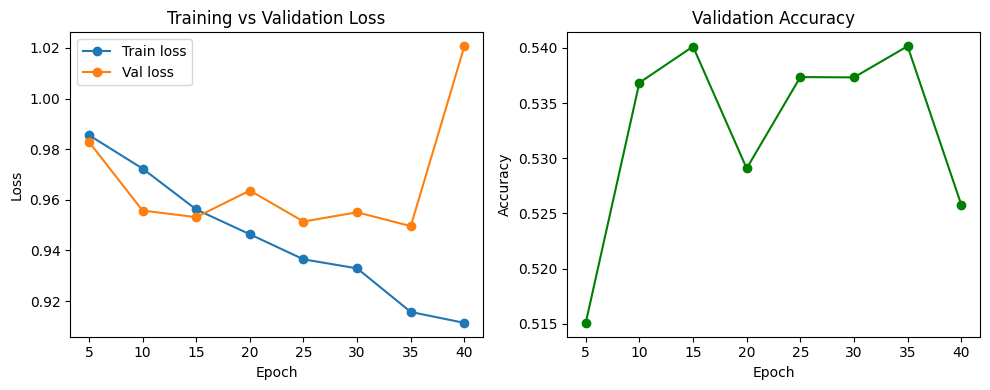

In [11]:
# ── Learning curves ────────────────────────────────────────────────────────────
epochs_logged = list(range(5, 5 * len(train_losses) + 1, 5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs_logged, train_losses, label="Train loss", marker="o")
ax1.plot(epochs_logged, val_losses,   label="Val loss",   marker="o")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()

ax2.plot(epochs_logged, val_accs, color="green", marker="o")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")

plt.tight_layout()
plt.savefig("learning_curves_transformer.png", dpi=150)
plt.show()


In [12]:
# ── Final evaluation (best model) ─────────────────────────────────────────────
model.load_state_dict(torch.load("transformer_best.pt", map_location=device))

preds, labels_arr = evaluate(model, test_loader)
print(classification_report(labels_arr, preds, target_names=le.classes_))


/tmp/ipykernel_657/3115064584.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("transformer_best.pt", map_location=device))


              precision    recall  f1-score   support

           C       0.55      0.49      0.52     12974
           E       0.48      0.29      0.36      6537
           H       0.54      0.71      0.62     13698

    accuracy                           0.54     33209
   macro avg       0.53      0.50      0.50     33209
weighted avg       0.54      0.54      0.53     33209



### Comparing to the BiLSTM

Both models were trained on identical BLOSUM62 features and the identical
train/test split (`random_state=42`), so the classification reports above and
in notebook 4 are directly comparable.
As we can see, the Transformer underperforms the BiLSTM. this is the expected symptom of
  attention's weaker inductive bias meeting a small (599-protein) dataset. 
  The LSTM's built-in sequential bias generalises better with less data.
